# Cyber-Physical Attack Surface Modeler — demo

A walkthrough of the pipeline on the **water-treatment** reference plant: load the model,
map ATT&CK for ICS techniques, score risk (NIST 800-30), find policy-respecting attack
paths, stress-test the scoring, and render the briefing figures.

Run from the repo root after `pip install -e ".[dev]"` (plus `pip install jupyter` for the
notebook).

In [1]:
import os

# notebooks run with cwd = notebooks/; hop to the repo root so data/ paths resolve
if os.path.basename(os.getcwd()) == "notebooks":
    os.chdir("..")

from ics_modeler.assets import load_architecture

arch = load_architecture("data/water_treatment.yaml")
print(arch.meta["name"], "—", len(arch.assets), "assets")
print("entry nodes:", arch.entry_nodes)
print("targets    :", arch.target_nodes)

Municipal Water Treatment Reference Plant — 14 assets
entry nodes: ['internet_gateway', 'remote_access_host']
targets    : ['dosing_plc', 'pump_plc']


## 1. Map assets → ATT&CK for ICS techniques

Data-driven rules ([`data/mapping_rules.yaml`](../data/mapping_rules.yaml)) map asset
attributes (protocol, component type, authentication) to techniques. Technique names are
resolved from the ATT&CK bundle when present.

In [2]:
from ics_modeler.mapping import load_rules, map_architecture

attack = None
if os.path.exists("data/attack_ics.json"):
    from ics_modeler.data_sources import load_attack_ics
    attack = load_attack_ics()

mapped = map_architecture(arch, load_rules("data/mapping_rules.yaml"), attack=attack)
for t in mapped["dosing_plc"]["techniques"]:
    print(t["id"], "—", t["name"] or "(install ATT&CK bundle for names)")

T0811 — Data from Information Repositories
T0821 — Modify Controller Tasking
T0836 — Modify Parameter
T0843 — Program Download
T0886 — Remote Services
T1692.001 — Command Message


## 2. Score risk (NIST SP 800-30 Table I-2)

Likelihood and impact are scored 0–100 and combined into a risk band via the 800-30
Table I-2 lookup. CVEs from the committed snapshot feed the known-exploited factor.

In [3]:
from ics_modeler.scoring import score_architecture

scores = score_architecture(arch)
print(f"{'asset':24} {'L':>5} {'I':>5}  band")
for name, s in sorted(scores.items(), key=lambda kv: -kv[1]["severity"])[:6]:
    print(f"{name:24} {s['likelihood']:5} {s['impact']:5}  {s['band']}")

asset                        L     I  band
dosing_plc                69.4  66.2  High
pump_plc                  69.4  63.1  High
distribution_rtu          69.4  63.1  High
chlorine_dosing_actuator  60.6  60.0  High
ph_sensor                 60.6  60.0  High
distribution_pump         60.6  60.0  High


## 3. Segmentation findings & attack paths

Attack paths run on the **reachability graph** — only edges the firewall policy permits.
The water plant leaves the remote-access host wired straight to the SCADA server, so the
model flags an IT→OT bypass (the Oldsmar pattern).

In [4]:
from ics_modeler.scoring import path_findings, segmentation_violations

for v in segmentation_violations(arch):
    print(f"BYPASS: {v['from']} -> {v['to']}  ({v['from_zone']} -> {v['to_zone']})")
print()
reach = arch.reachability_graph()
for p in path_findings(reach, arch.entry_nodes, arch.target_nodes, scores)[:3]:
    print(f"[{p['length']} hops, cost {p['cost']}] " + " -> ".join(p["path"]))

BYPASS: remote_access_host -> scada_server  (L4_ENTERPRISE -> L2_SUPERVISORY)

[2 hops, cost 2.0] remote_access_host -> scada_server -> dosing_plc
[2 hops, cost 2.0] remote_access_host -> scada_server -> pump_plc
[4 hops, cost 5.0] internet_gateway -> business_workstation -> remote_access_host -> scada_server -> dosing_plc


## 4. Sensitivity — are the rankings robust to the weights?

The factor weights are an engineering heuristic, so we stress-test them: re-score under
all ±20% weight perturbations and check what stays stable.

In [5]:
from ics_modeler.scoring import sensitivity

r = sensitivity(arch)
print(f"perturbations    : {r['perturbations']}")
print(f"top-1 stable     : {r['top1_stable_fraction'] * 100:.0f}%")
print(f"per-asset band   : {r['band_stable_fraction'] * 100:.0f}% stable")
print(f"baseline top-3   : {r['baseline_top_n']}")

perturbations    : 81
top-1 stable     : 100%
per-asset band   : 71% stable
baseline top-3   : ['dosing_plc', 'pump_plc', 'distribution_rtu']


## 5. Generate the briefing + figures

`build()` runs the whole pipeline and writes the briefing and figures. Below is the asset
graph it renders (color = Purdue level, size = impact).

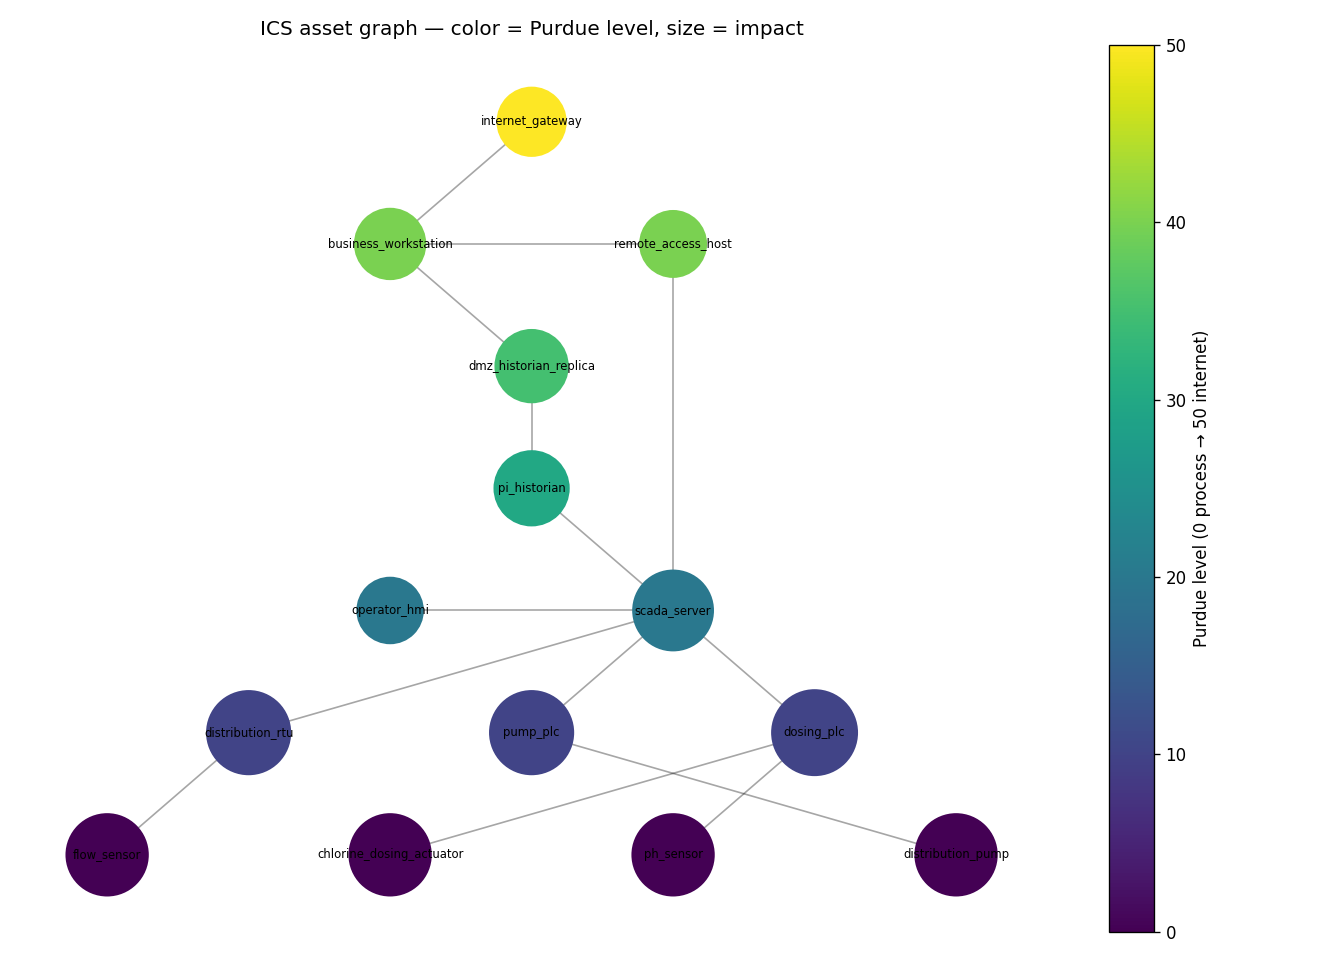

In [6]:
from ics_modeler.pipeline import build
from IPython.display import Image

build(arch_path="data/water_treatment.yaml", out_dir="examples/water_treatment")
Image("examples/water_treatment/figures/network.png")